# 🛒 Market Basket Analysis Using Apriori Algorithm

## Objective
Identify products that are frequently purchased together and discover association rules to improve cross-selling, product recommendations, promotions, and business decision-making.


## 1. Install Required Library

In [20]:
!pip install mlxtend

## 2. Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 3. Load the Dataset

In [3]:
# Update the filename if your CSV has a different name
df = pd.read_csv("basket_analysis.csv")

df.head()

,Unnamed: 0,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 4. Basic Dataset Information

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (999, 17)

Column Names:
['Unnamed: 0', 'Apple', 'Bread', 'Butter', 'Cheese', 'Corn', 'Dill', 'Eggs', 'Ice cream', 'Kidney Beans', 'Milk', 'Nutmeg', 'Onion', 'Sugar', 'Unicorn', 'Yogurt', 'chocolate']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    999 non-null    int64
 1   Apple         999 non-null    bool 
 2   Bread         999 non-null    bool 
 3   Butter        999 non-null    bool 
 4   Cheese        999 non-null    bool 
 5   Corn          999 non-null    bool 
 6   Dill          999 non-null    bool 
 7   Eggs          999 non-null    bool 
 8   Ice cream     999 non-null    bool 
 9   Kidney Beans  999 non-null    bool 
 10  Milk          999 non-null    bool 
 11  Nutmeg        999 non-null    bool 
 12  Onion         999 non-null    bool 
 13  Sugar         999 non-null    bool 
 

## 5. Data Preprocessing

In [5]:
# Remove unnecessary index column if present
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Convert transaction values to Boolean format
df = df.astype(bool)

df.head()

,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Check Missing Values

In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Apple           0
Bread           0
Butter          0
Cheese          0
Corn            0
Dill            0
Eggs            0
Ice cream       0
Kidney Beans    0
Milk            0
Nutmeg          0
Onion           0
Sugar           0
Unicorn         0
Yogurt          0
chocolate       0
dtype: int64


## 6. Exploratory Data Analysis

In [7]:
print("Total Number of Transactions:", len(df))
print("Total Number of Products:", len(df.columns))

product_frequency = df.sum().sort_values(ascending=False)

print("\nProduct Purchase Frequency:")
print(product_frequency)

Total Number of Transactions: 999
Total Number of Products: 16

Product Purchase Frequency:
chocolate       421
Butter          420
Yogurt          420
Ice cream       410
Sugar           409
Kidney Beans    408
Corn            407
Milk            405
Cheese          404
Onion           403
Nutmeg          401
Dill            398
Unicorn         389
Bread           384
Eggs            384
Apple           383
dtype: int64


### Visualization: Product Purchase Frequency

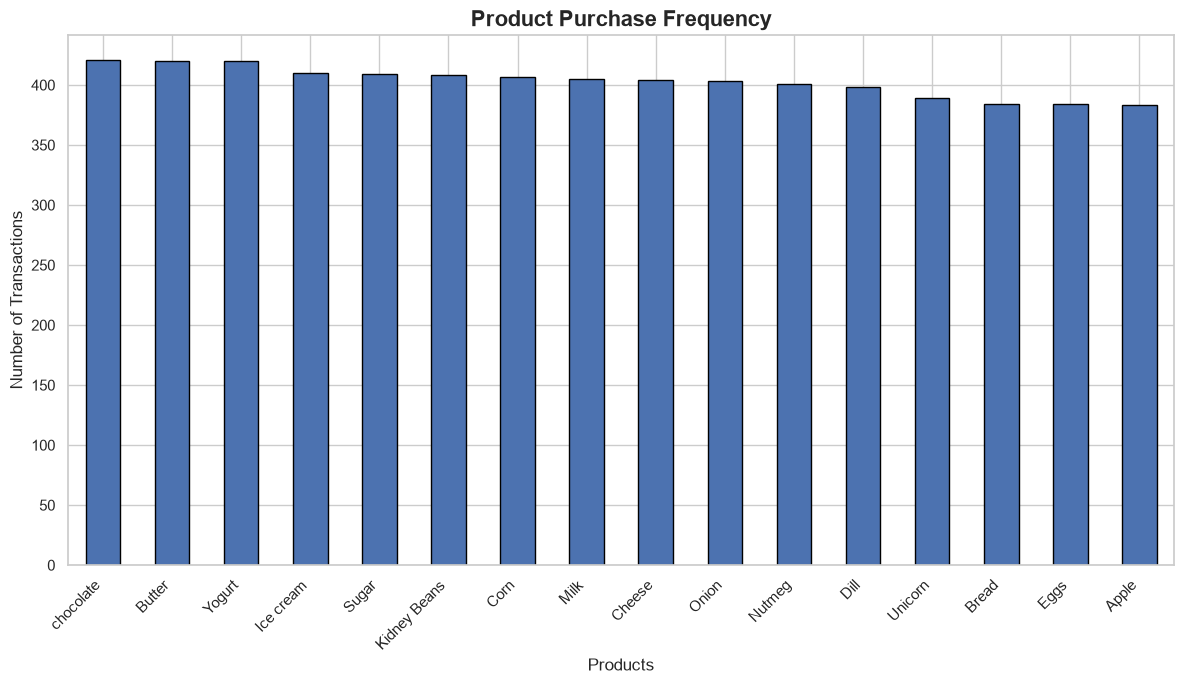

In [8]:
plt.figure(figsize=(12, 7))

product_frequency.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Product Purchase Frequency", fontsize=16, fontweight="bold")
plt.xlabel("Products")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Interpretation
The chart shows which products are purchased most frequently. Popular products can be used as anchor products for promotions, recommendations, and cross-selling strategies.


## 7. Apply the Apriori Algorithm

In [9]:
frequent_itemsets = apriori(
    df,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets.head(10)

,support,itemsets
15,0.421421,(chocolate)
2,0.420420,(Butter)
14,0.420420,(Yogurt)
7,0.410410,(Ice cream)
12,0.409409,(Sugar)
8,0.408408,(Kidney Beans)
4,0.407407,(Corn)
9,0.405405,(Milk)
3,0.404404,(Cheese)
11,0.403403,(Onion)


## 8. Visualize Top Frequent Itemsets

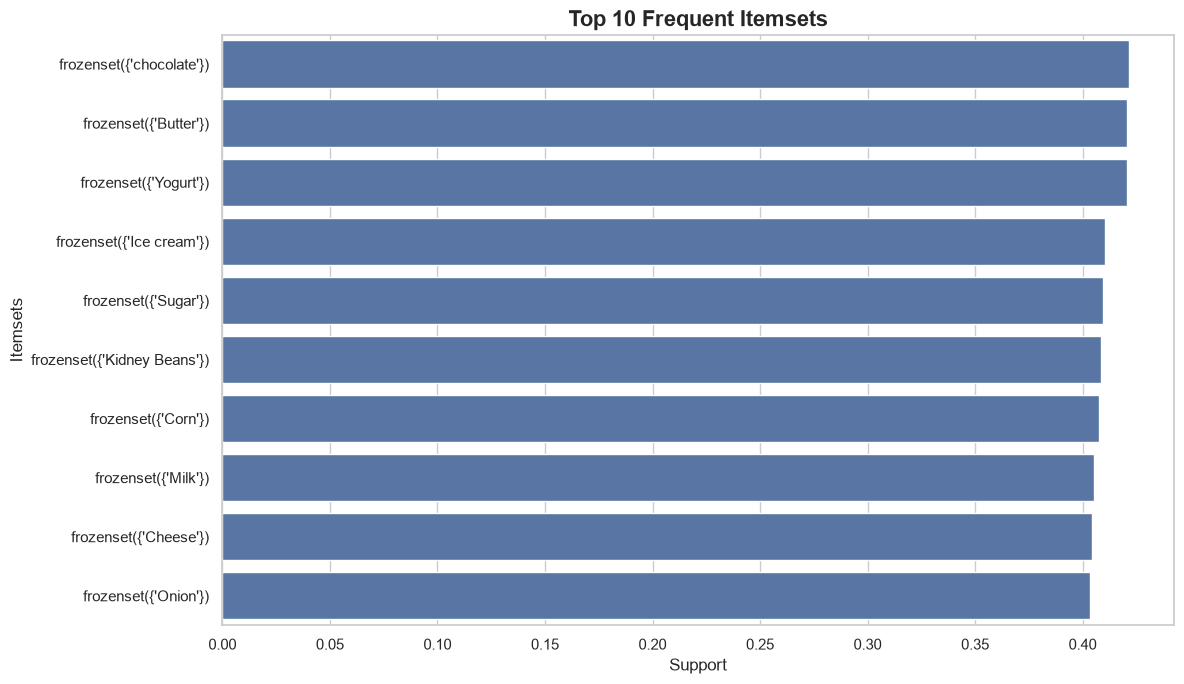

In [10]:
top_itemsets = frequent_itemsets.head(10).copy()
top_itemsets["itemsets"] = top_itemsets["itemsets"].astype(str)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_itemsets,
    x="support",
    y="itemsets"
)

plt.title("Top 10 Frequent Itemsets", fontsize=16, fontweight="bold")
plt.xlabel("Support")
plt.ylabel("Itemsets")

plt.tight_layout()
plt.show()

### Interpretation
Frequent itemsets represent products that commonly occur together in customer transactions. Higher support means that the product combination appears more frequently.


## 9. Generate Association Rules

In [11]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(chocolate),(Milk),0.421421,0.405405,0.211211,0.501188,1.236263,1.0,0.040365,1.192021,0.330310,0.343089,0.161088,0.511088
1,(Milk),(chocolate),0.405405,0.421421,0.211211,0.520988,1.236263,1.0,0.040365,1.207857,0.321413,0.343089,0.172088,0.511088
2,(Butter),(Ice cream),0.420420,0.410410,0.207207,0.492857,1.200889,1.0,0.034662,1.162571,0.288629,0.332263,0.139837,0.498868
3,(Ice cream),(Butter),0.410410,0.420420,0.207207,0.504878,1.200889,1.0,0.034662,1.170579,0.283728,0.332263,0.145722,0.498868
4,(Butter),(chocolate),0.420420,0.421421,0.202202,0.480952,1.141262,1.0,0.025028,1.114693,0.213564,0.316119,0.102892,0.480381


### Important Rule Metrics

In [12]:
rules_display = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

rules_display.head(10)

,antecedents,consequents,support,confidence,lift
0,(chocolate),(Milk),0.211211,0.501188,1.236263
1,(Milk),(chocolate),0.211211,0.520988,1.236263
2,(Butter),(Ice cream),0.207207,0.492857,1.200889
3,(Ice cream),(Butter),0.207207,0.504878,1.200889
4,(Butter),(chocolate),0.202202,0.480952,1.141262
5,(chocolate),(Butter),0.202202,0.479810,1.141262
6,(Kidney Beans),(Butter),0.202202,0.495098,1.177626
7,(Butter),(Kidney Beans),0.202202,0.480952,1.177626
8,(chocolate),(Ice cream),0.202202,0.479810,1.169098
9,(Ice cream),(chocolate),0.202202,0.492683,1.169098


## 10. Sort Association Rules by Lift

In [13]:
rules_sorted = rules.sort_values(
    by="lift",
    ascending=False
)

rules_sorted[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)

,antecedents,consequents,support,confidence,lift
2092,"(Cheese, Dill)","(Kidney Beans, Onion)",0.055055,0.310734,1.826022
2090,"(Kidney Beans, Onion)","(Cheese, Dill)",0.055055,0.323529,1.826022
1933,"(chocolate, Onion)","(Dill, Unicorn)",0.060060,0.306122,1.820335
1938,"(Dill, Unicorn)","(chocolate, Onion)",0.060060,0.357143,1.820335
2026,"(Kidney Beans, Dill)","(chocolate, Cheese)",0.057057,0.331395,1.779914
2027,"(chocolate, Cheese)","(Kidney Beans, Dill)",0.057057,0.306452,1.779914
2121,"(Apple, Unicorn)","(Corn, Sugar)",0.055055,0.331325,1.770021
2033,"(Kidney Beans, Bread)","(Corn, Milk)",0.057057,0.341317,1.766715
1924,"(chocolate, Unicorn)","(Milk, Dill)",0.062062,0.333333,1.752632
1928,"(Milk, Dill)","(chocolate, Unicorn)",0.062062,0.326316,1.752632


## 11. Filter Strong Association Rules

In [14]:
strong_rules = rules[
    (rules["confidence"] >= 0.30) &
    (rules["lift"] > 1)
].copy()

strong_rules = strong_rules.sort_values(
    by="lift",
    ascending=False
)

strong_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)

,antecedents,consequents,support,confidence,lift
2092,"(Cheese, Dill)","(Kidney Beans, Onion)",0.055055,0.310734,1.826022
2090,"(Kidney Beans, Onion)","(Cheese, Dill)",0.055055,0.323529,1.826022
1933,"(chocolate, Onion)","(Dill, Unicorn)",0.060060,0.306122,1.820335
1938,"(Dill, Unicorn)","(chocolate, Onion)",0.060060,0.357143,1.820335
2027,"(chocolate, Cheese)","(Kidney Beans, Dill)",0.057057,0.306452,1.779914
2026,"(Kidney Beans, Dill)","(chocolate, Cheese)",0.057057,0.331395,1.779914
2121,"(Apple, Unicorn)","(Corn, Sugar)",0.055055,0.331325,1.770021
2033,"(Kidney Beans, Bread)","(Corn, Milk)",0.057057,0.341317,1.766715
1924,"(chocolate, Unicorn)","(Milk, Dill)",0.062062,0.333333,1.752632
1928,"(Milk, Dill)","(chocolate, Unicorn)",0.062062,0.326316,1.752632


## 12. Visualization: Support vs Confidence

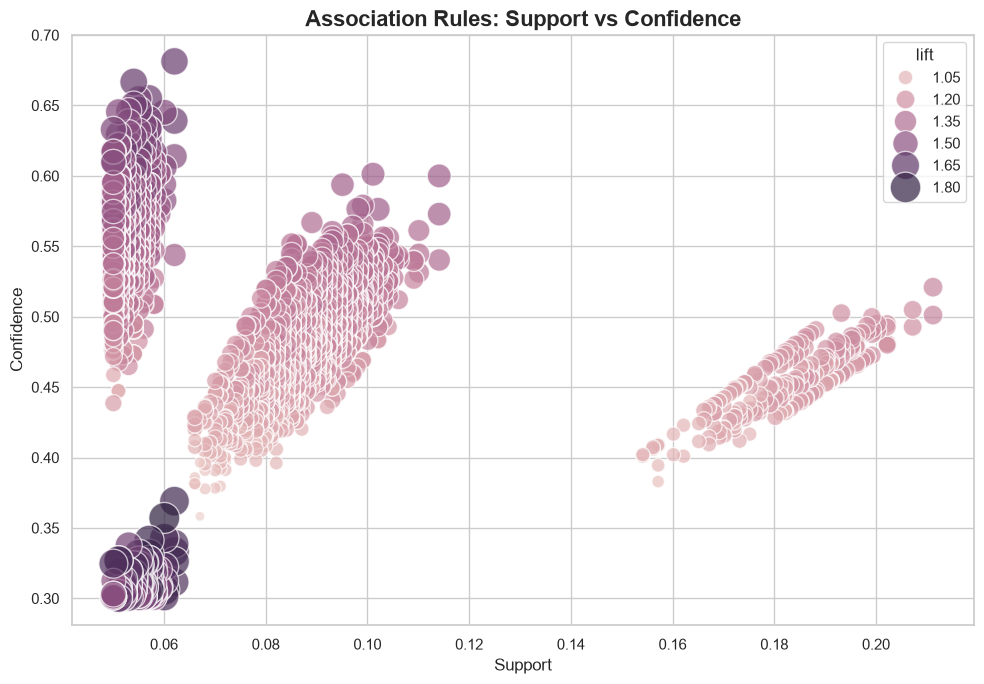

In [15]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    size="lift",
    hue="lift",
    sizes=(50, 500),
    alpha=0.7
)

plt.title(
    "Association Rules: Support vs Confidence",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.tight_layout()
plt.show()

### Interpretation
Rules with higher support and confidence are generally more useful. Larger points represent higher lift values, indicating stronger product associations.


## 13. Visualization: Top Association Rules by Lift

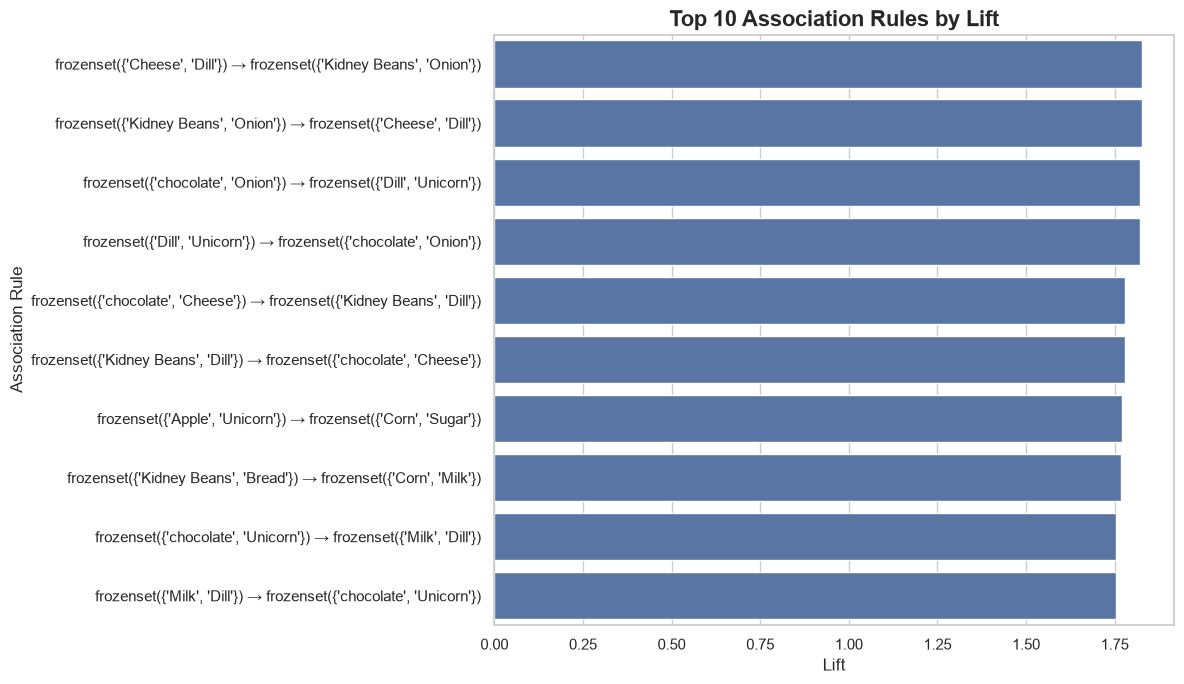

In [16]:
top_rules = strong_rules.head(10).copy()

top_rules["Rule"] = (
    top_rules["antecedents"].astype(str)
    + " → " +
    top_rules["consequents"].astype(str)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_rules,
    x="lift",
    y="Rule"
)

plt.title(
    "Top 10 Association Rules by Lift",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")

plt.tight_layout()
plt.show()

### Interpretation
Rules with higher lift values indicate stronger-than-random relationships between products. These rules provide valuable opportunities for cross-selling and product recommendations.


## 14. Business Insights

In [17]:
print("BUSINESS INSIGHTS")
print("=" * 60)

print("""
1. Frequently purchased products can be promoted alongside related products.

2. Strong association rules can be used for product recommendations.

3. Businesses can create product bundles based on frequently occurring itemsets.

4. Store layouts can be optimized by placing associated products closer together.

5. Products with high lift values provide valuable cross-selling opportunities.

6. E-commerce platforms can use these rules for personalized recommendations.
""")

BUSINESS INSIGHTS

1. Frequently purchased products can be promoted alongside related products.

2. Strong association rules can be used for product recommendations.

3. Businesses can create product bundles based on frequently occurring itemsets.

4. Store layouts can be optimized by placing associated products closer together.

5. Products with high lift values provide valuable cross-selling opportunities.

6. E-commerce platforms can use these rules for personalized recommendations.



## 15. Final Conclusion

In [18]:
print("""
CONCLUSION

Market Basket Analysis was successfully performed using the Apriori algorithm.

The analysis identified frequently purchased products and association rules
between products. Support measured how frequently itemsets occurred,
confidence measured the reliability of association rules, and lift measured
the strength of relationships between products.

The identified associations can help businesses improve cross-selling,
product recommendations, promotional campaigns, product placement,
and customer experience.
""")


CONCLUSION

Market Basket Analysis was successfully performed using the Apriori algorithm.

The analysis identified frequently purchased products and association rules
between products. Support measured how frequently itemsets occurred,
confidence measured the reliability of association rules, and lift measured
the strength of relationships between products.

The identified associations can help businesses improve cross-selling,
product recommendations, promotional campaigns, product placement,
and customer experience.

